In [ ]:
import pandas as pd

In [ ]:
df= pd.read_csv("diabetes.csv")

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
y=df["Outcome"]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Statistical Analysis

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
(df == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


Correlation Heatmap

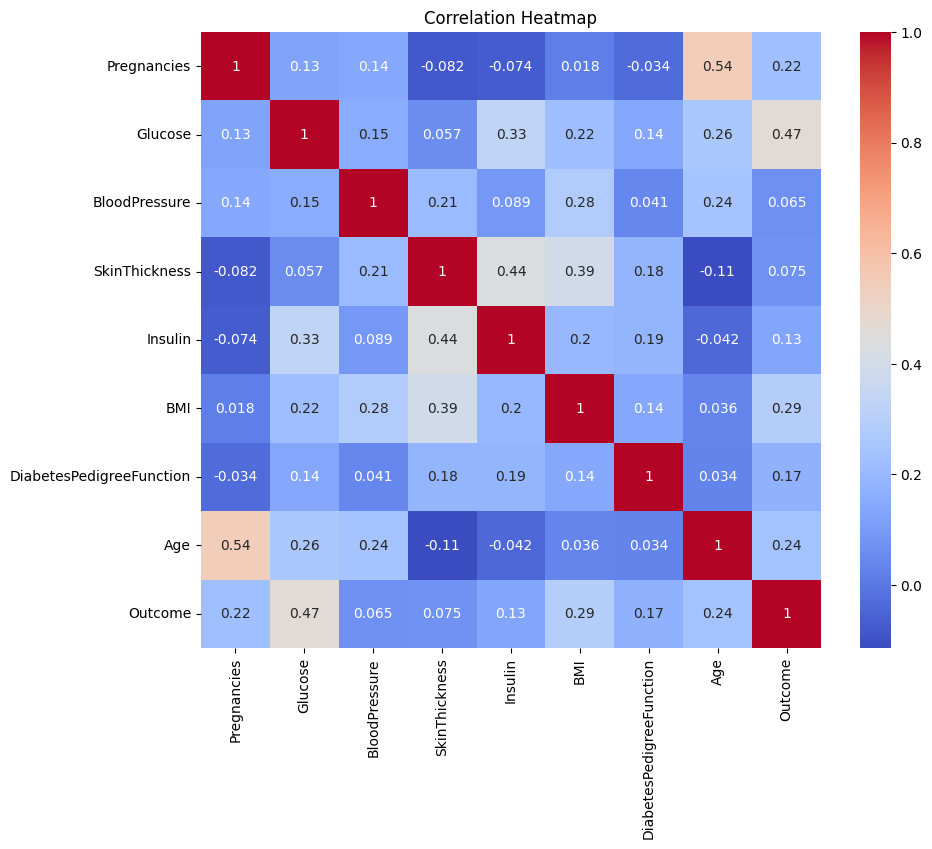

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

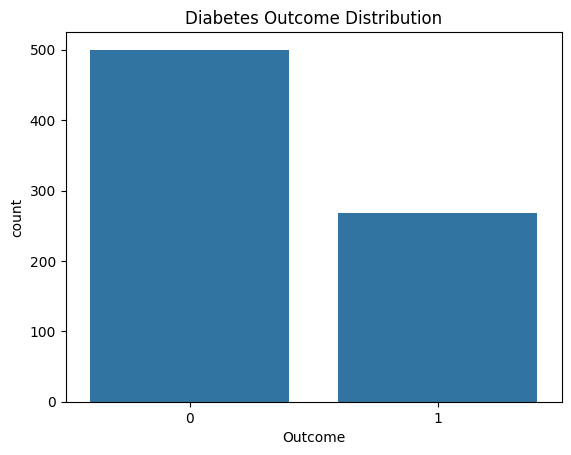

In [ ]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()

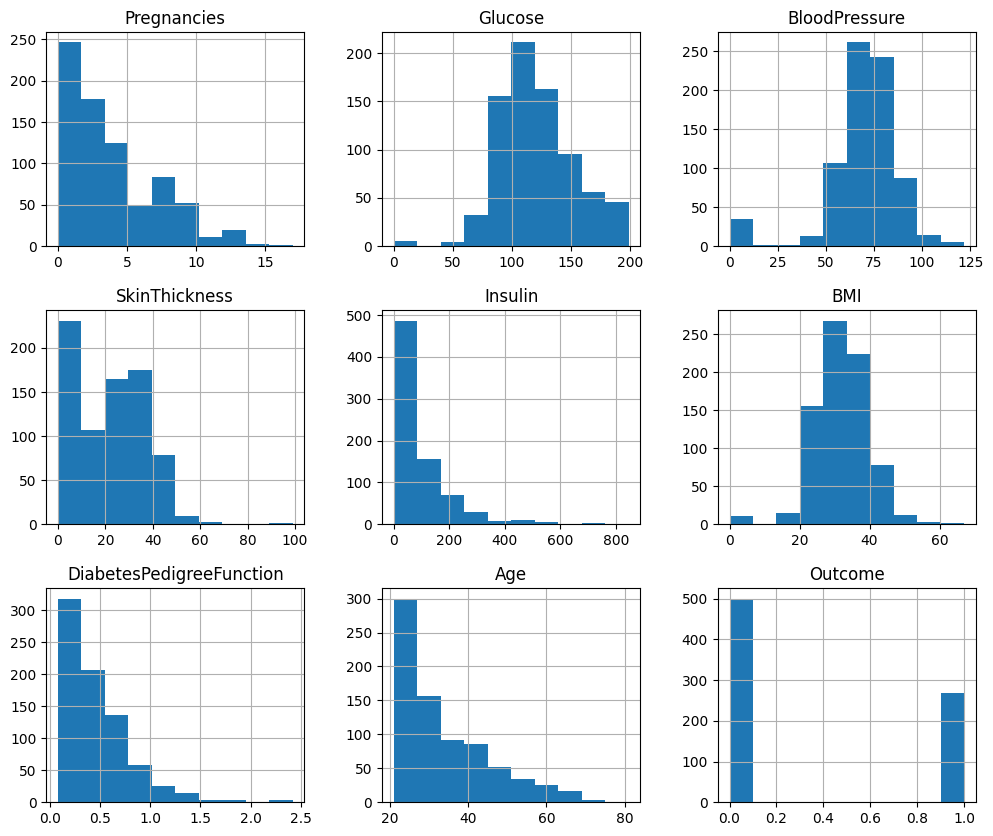

In [ ]:
df.hist(figsize=(12,10))
plt.show()

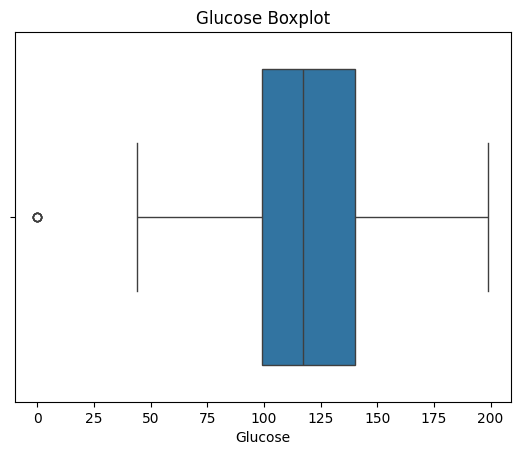

In [ ]:
sns.boxplot(x=df['Glucose'])
plt.title("Glucose Boxplot")
plt.show()

# Model 2 (Decision Tree)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd

 **Features and target**

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

**Split dataset**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Feature Scaling**

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Decision Tree model**

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

**Train model**

In [ ]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

 **Predictions**

In [ ]:
y_pred = dt_model.predict(X_test)

**Accuracy**

In [ ]:
dt_accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7467532467532467


**Classification Report**

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.76      0.79        99
           1       0.62      0.73      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



**Confusion Matrix**

In [ ]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:

[[75 24]
 [15 40]]


# Model 1 (SVM)


*Note: We did not split or scale the data here.We are using the same scaled data (X_train, X_test) from Model 2 to make a fair comparison between the two models.*


In [ ]:
#import pandas as pd
#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Features and target**

In [ ]:
# X = df.drop("Outcome", axis=1)
# y = df["Outcome"]

**Split dataset**

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

**Feature scaling**

In [ ]:
# scaler = StandardScaler()

In [ ]:
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

**SVM model**

In [ ]:
svm_model = SVC(kernel='linear', random_state=42)

**Train model**

In [ ]:
svm_model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

**Predictions**

In [ ]:
y_pred_svm = svm_model.predict(X_test)

**Accuracy**

In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

In [ ]:
print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.7597402597402597


**Classification Report**

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))


Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.82      0.81        99
           1       0.67      0.65      0.66        55

    accuracy                           0.76       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.76      0.76       154



**Confusion Matrix**

In [ ]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))


Confusion Matrix:

[[81 18]
 [19 36]]


# Model 3 (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

**Train model**

In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Predictions**

In [ ]:
y_pred_rf = rf_model.predict(X_test)

**Accuracy**

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7207792207792207


**Classification Report**

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



**Confusion Matrix**

In [ ]:
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))


Confusion Matrix:

[[77 22]
 [21 34]]


**Feature Importance Analysis**

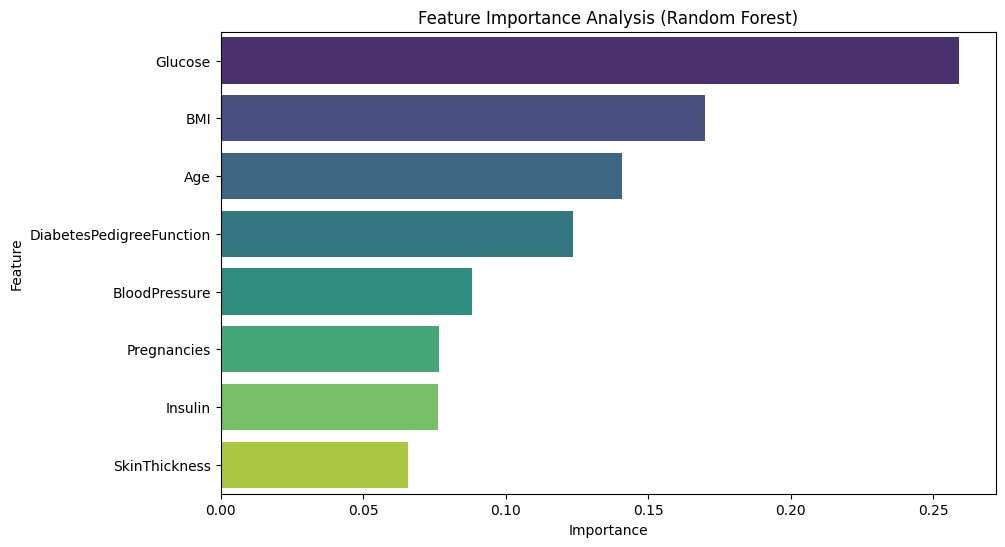

In [ ]:
importances = rf_model.feature_importances_
features = X.columns

feature_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_df, hue='Feature', palette='viridis', legend=False)
plt.title("Feature Importance Analysis (Random Forest)")
plt.show()

**Feature Importance Analysis:**
This chart shows that Glucose is the most significant factor in predicting diabetes in our dataset, followed by BMI and Age.

**Random Forest Baseline Model**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    random_state=42,
    n_jobs=1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_baseline_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_baseline_accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7207792207792207

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154


Confusion Matrix:

[[77 22]
 [21 34]]


# Hyperparameter Tuning / Optimization Strategy

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

**SVM tuning**

In [ ]:
svm_params = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1]
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    svm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

svm_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42), n_jobs=1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.1],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='accuracy')

**Decision Tree tuning**

In [ ]:
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

dt_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 7, 10],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

**Random Forest tuning**

In [ ]:
rf_params = {
    'n_estimators': [10, 50, 100],
    'max_depth': [None, 3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=1),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=1, random_state=42),
             n_jobs=1,
             param_grid={'max_depth': [None, 3, 5, 7],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [10, 50, 100]},
             scoring='accuracy')

**Evaluation of Tuned Models**

In [ ]:
tuned_results = []

models_info = {
    "SVM": (svm_grid.best_estimator_, svm_grid.best_params_),
    "Decision Tree": (dt_grid.best_estimator_, dt_grid.best_params_),
    "Random Forest": (rf_grid.best_estimator_, rf_grid.best_params_)
}

for model_name, (model, best_params) in models_info.items():
    y_pred = model.predict(X_test)

    tuned_results.append({
        "Model": model_name,
        "Best Parameters": best_params,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1-score": f1_score(y_test, y_pred, average='weighted')
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,Best Parameters,Accuracy,Precision,Recall,F1-score
0,SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.733766,0.727959,0.733766,0.729265
1,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.759740,0.755907,0.759740,0.756979
2,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.740260,0.742501,0.740260,0.741254


In [ ]:
display_results = tuned_results_df.copy()

for col in ["Accuracy", "Precision", "Recall", "F1-score"]:
    display_results[col] = (display_results[col] * 100).round(2).astype(str) + "%"

display_results

,Model,Best Parameters,Accuracy,Precision,Recall,F1-score
0,SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",73.38%,72.8%,73.38%,72.93%
1,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",75.97%,75.59%,75.97%,75.7%
2,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",74.03%,74.25%,74.03%,74.13%


**Best Parameters Summary**

In [ ]:
best_params_summary = pd.DataFrame({
    "Model": ["SVM", "Decision Tree", "Random Forest"],
    "Best Parameters": [
        svm_grid.best_params_,
        dt_grid.best_params_,
        rf_grid.best_params_
    ],
    "Best Cross-Validation Accuracy": [
        svm_grid.best_score_,
        dt_grid.best_score_,
        rf_grid.best_score_
    ]
})

best_params_summary

,Model,Best Parameters,Best Cross-Validation Accuracy
0,SVM,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",0.768746
1,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_sam...",0.759016
2,Random Forest,"{'max_depth': None, 'min_samples_leaf': 1, 'mi...",0.781794


**Baseline vs Tuned Models**

In [ ]:
baseline_vs_tuned = pd.DataFrame({
    "Model": ["SVM", "Decision Tree", "Random Forest"],
    "Baseline Accuracy": [svm_accuracy, dt_accuracy, rf_accuracy],
    "Tuned Accuracy": [
        tuned_results_df.loc[tuned_results_df["Model"] == "SVM", "Accuracy"].values[0],
        tuned_results_df.loc[tuned_results_df["Model"] == "Decision Tree", "Accuracy"].values[0],
        tuned_results_df.loc[tuned_results_df["Model"] == "Random Forest", "Accuracy"].values[0]
    ]
})

baseline_vs_tuned["Change"] = baseline_vs_tuned["Tuned Accuracy"] - baseline_vs_tuned["Baseline Accuracy"]
baseline_vs_tuned

,Model,Baseline Accuracy,Tuned Accuracy,Change
0,SVM,0.759740,0.733766,-0.025974
1,Decision Tree,0.746753,0.759740,0.012987
2,Random Forest,0.720779,0.740260,0.019481


In [ ]:
baseline_vs_tuned_display = baseline_vs_tuned.copy()

for col in ["Baseline Accuracy", "Tuned Accuracy", "Change"]:
    baseline_vs_tuned_display[col] = (baseline_vs_tuned_display[col] * 100).round(2).astype(str) + "%"

baseline_vs_tuned_display

,Model,Baseline Accuracy,Tuned Accuracy,Change
0,SVM,75.97%,73.38%,-2.6%
1,Decision Tree,74.68%,75.97%,1.3%
2,Random Forest,72.08%,74.03%,1.95%


## **Optimization Graphs**

**SVM graph**

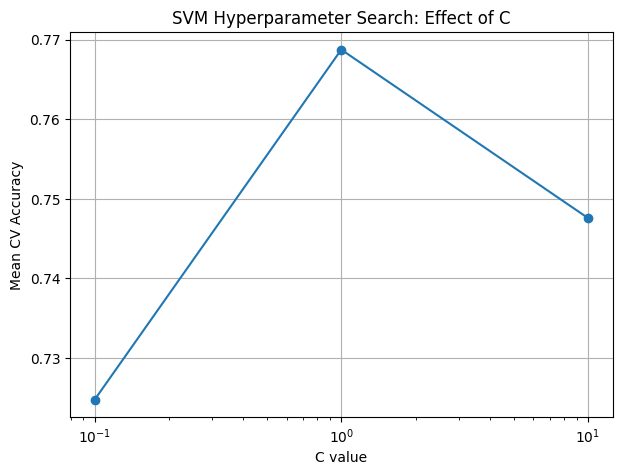

In [ ]:
import matplotlib.pyplot as plt

svm_results = pd.DataFrame(svm_grid.cv_results_)

svm_plot = svm_results[
    (svm_results['param_kernel'] == 'rbf') &
    (svm_results['param_gamma'] == 'scale')
]

plt.figure(figsize=(7,5))
plt.plot(svm_plot['param_C'], svm_plot['mean_test_score'], marker='o')
plt.xlabel("C value")
plt.ylabel("Mean CV Accuracy")
plt.title("SVM Hyperparameter Search: Effect of C")
plt.xscale("log")
plt.grid(True)
plt.show()

**Decision Tree graph**

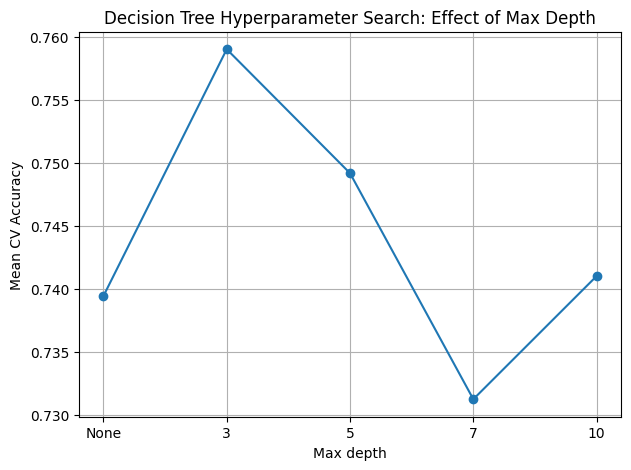

In [ ]:
dt_results = pd.DataFrame(dt_grid.cv_results_)

dt_plot = dt_results[
    (dt_results['param_criterion'] == 'gini') &
    (dt_results['param_min_samples_split'] == 2) &
    (dt_results['param_min_samples_leaf'] == 4)
]

plt.figure(figsize=(7,5))
plt.plot(dt_plot['param_max_depth'].astype(str), dt_plot['mean_test_score'], marker='o')
plt.xlabel("Max depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Decision Tree Hyperparameter Search: Effect of Max Depth")
plt.grid(True)
plt.show()

**Random Forest graph**

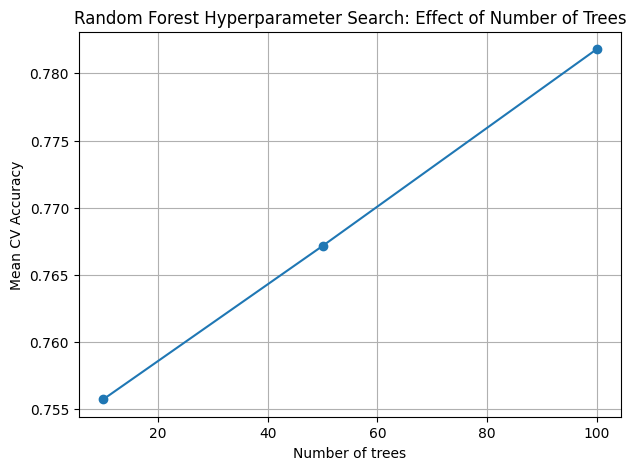

In [ ]:
rf_results = pd.DataFrame(rf_grid.cv_results_)

rf_plot = rf_results[
    (rf_results['param_max_depth'].isna()) &
    (rf_results['param_min_samples_split'] == 5) &
    (rf_results['param_min_samples_leaf'] == 1)
]

plt.figure(figsize=(7,5))
plt.plot(rf_plot['param_n_estimators'], rf_plot['mean_test_score'], marker='o')
plt.xlabel("Number of trees")
plt.ylabel("Mean CV Accuracy")
plt.title("Random Forest Hyperparameter Search: Effect of Number of Trees")
plt.grid(True)
plt.show()

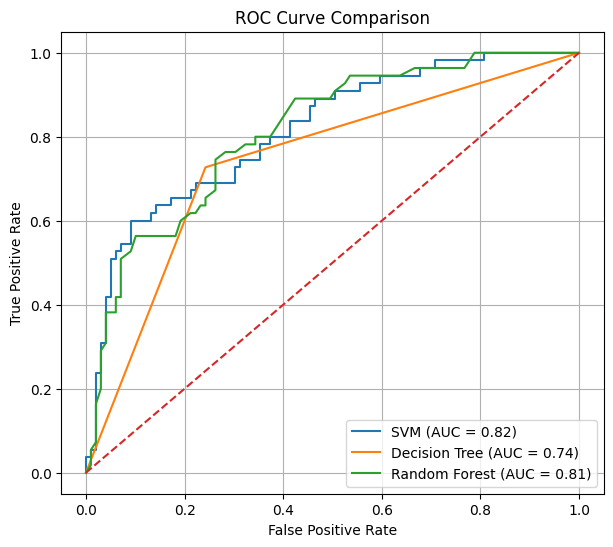

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

models = {
    "SVM": svm_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

for name, model in models.items():

    # SVM in your notebook does not use probability=True,
    # so we use decision_function if available.
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()